# Post 01: Initialize an MD Simulation Without Biasing the Result

This notebook is the presentation layer for the first tutorial. The reusable initialization, provenance, and figure logic lives in `src/kups_md_tutorials/`.

The goal is to make the initial state auditable: the cell, structure, velocity draw, center-of-mass removal, seed, config hash, and software versions should all be recoverable from committed files.

In [1]:
from pathlib import Path
import json
import os

from IPython.display import Image, display

repo_root = Path.cwd()
if not (repo_root / "configs").exists():
    repo_root = repo_root.parent
os.chdir(repo_root)
repo_root

PosixPath('/home/sungs/kups-md-tutorials')

In [2]:
from kups_md_tutorials.config import load_tutorial_spec
from kups_md_tutorials.figures import generate_post01_figures
from kups_md_tutorials.initialization import initialize_atoms, summarize_initialization
from kups_md_tutorials.provenance import provenance

## Configuration

The smoke profile is intentionally small enough to run on CPU, but it uses the same code path as larger profiles. The configuration fixes the argon FCC density, the velocity seed, and whether the center-of-mass momentum is removed.

In [3]:
spec = load_tutorial_spec("01", "smoke")
config_path = Path("configs/post-01/smoke.json")
print(json.dumps(json.loads(config_path.read_text()), indent=2))

{
  "post": "01",
  "profile": "smoke",
  "title": "How Do You Initialize an MD Simulation Without Biasing the Result?",
  "system": {
    "kind": "argon_fcc",
    "repetitions": 2,
    "number_density": 0.0213
  },
  "initialization": {
    "temperature_k": 94.4,
    "seed": 2026071401,
    "remove_center_of_mass": true,
    "force_exact_temperature": false
  }
}


## Deterministic initial state

A reproducible initial state is not only a set of coordinates. It also includes the random velocity draw and post-processing choices such as center-of-mass removal. The instantaneous kinetic temperature is allowed to fluctuate because the smoke profile samples Maxwell-Boltzmann momenta without forcing the exact target temperature.

In [4]:
atoms = initialize_atoms(spec)
summary = summarize_initialization(atoms, spec, provenance(config_path).config_sha256)
summary

InitializationSummary(post='01', profile='smoke', atom_count=32, chemical_formula='Ar32', volume=1502.3474178403744, number_density=0.021300000000000017, target_temperature_k=94.4, instantaneous_temperature_k=103.23132783754575, kinetic_energy_ev=0.42699765750033536, center_of_mass_speed=7.045623056532181e-19, seed=2026071401, config_sha256='0d654a2a2097eac2e54cd3a59f9d2cc77f18641618f3bcdcc0e045deea52a848')

## Committed smoke output

The repository commits compact smoke outputs so later changes can be checked against a known initial state. Larger raw trajectories remain outside version control.

In [5]:
result_dir = Path("results/post-01/smoke")
for path in sorted(result_dir.iterdir()):
    print(f"{path}: {path.stat().st_size} bytes")

committed_summary = json.loads((result_dir / "initialization_summary.json").read_text())
committed_summary

results/post-01/smoke/initial_state.extxyz: 3509 bytes
results/post-01/smoke/initialization_summary.json: 452 bytes
results/post-01/smoke/manifest.json: 945 bytes


{'atom_count': 32,
 'center_of_mass_speed': 7.045623056532181e-19,
 'chemical_formula': 'Ar32',
 'config_sha256': '0d654a2a2097eac2e54cd3a59f9d2cc77f18641618f3bcdcc0e045deea52a848',
 'instantaneous_temperature_k': 103.23132783754575,
 'kinetic_energy_ev': 0.42699765750033536,
 'number_density': 0.021300000000000017,
 'post': '01',
 'profile': 'smoke',
 'seed': 2026071401,
 'target_temperature_k': 94.4,
 'volume': 1502.3474178403744}

## Diagnostic figure

This figure is a compact check of three initialization facts: the density implied by the cell, the seeded velocity draw, and provenance checks that should remain stable across runs.

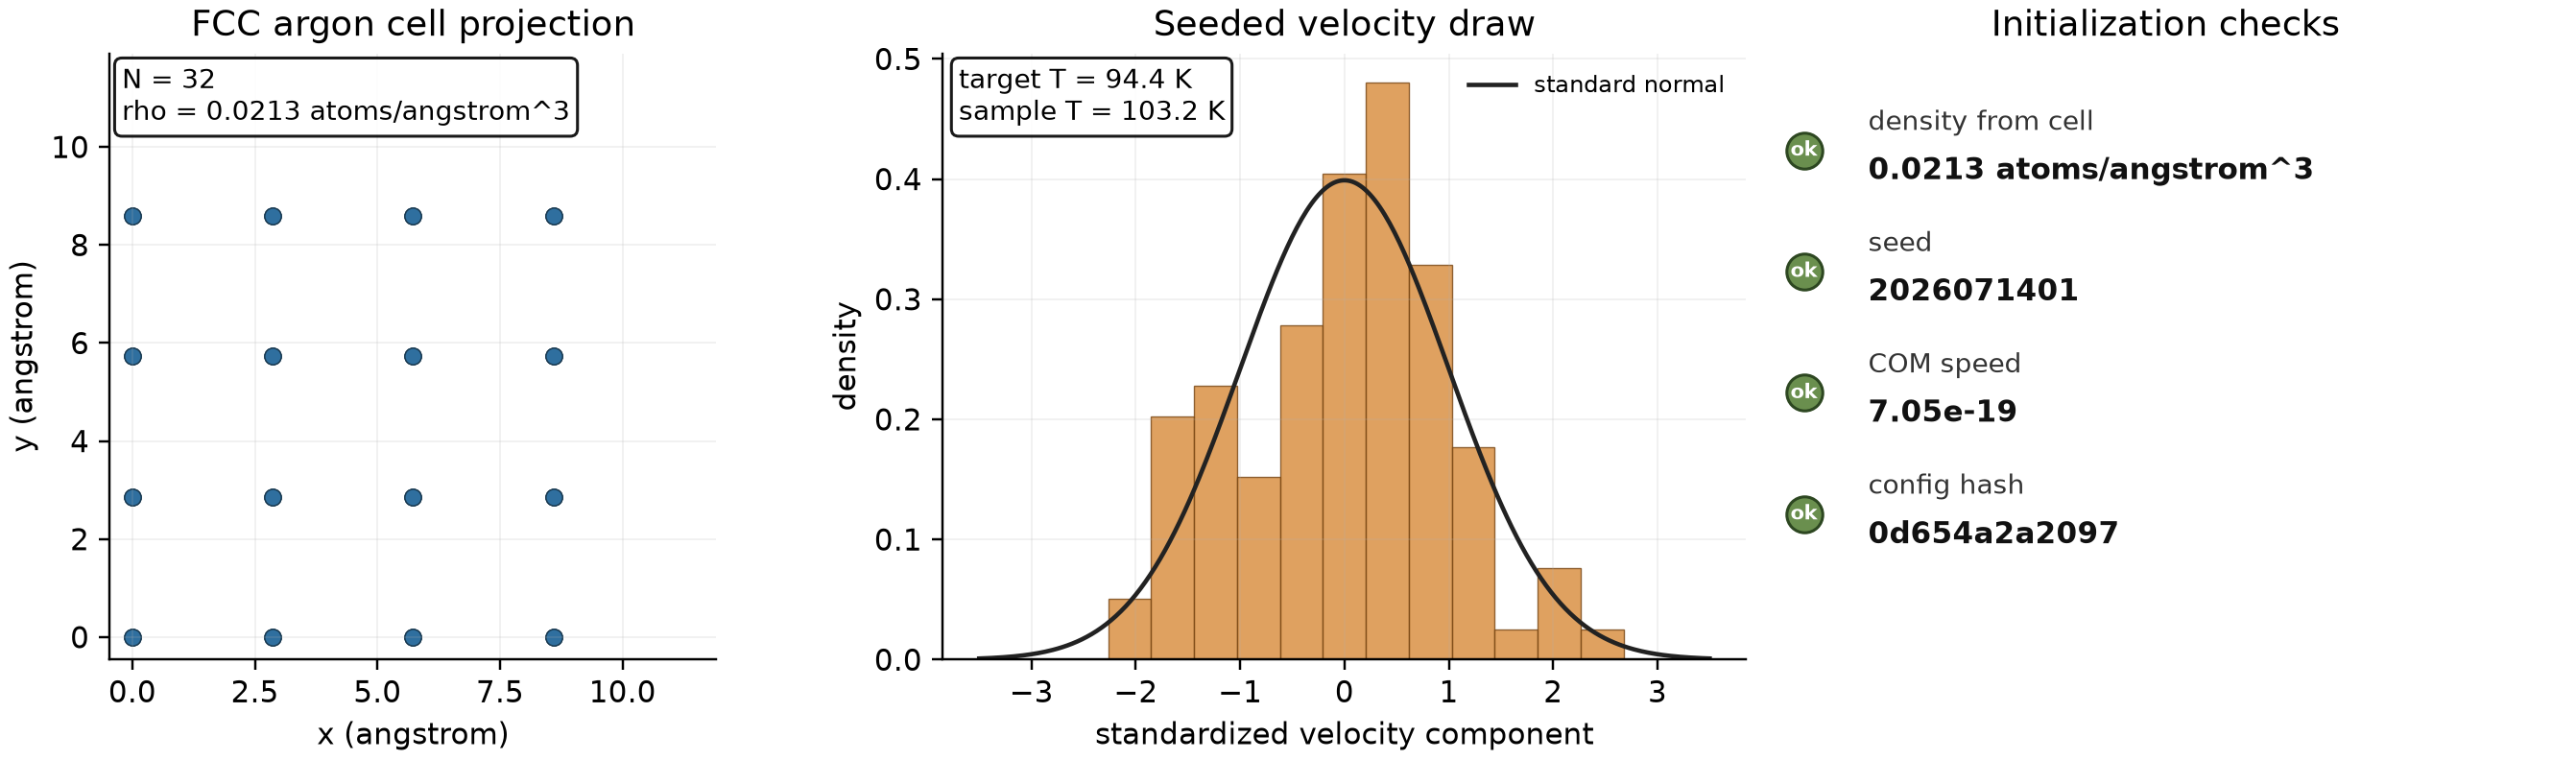

In [6]:
generate_post01_figures(
    result_dir=result_dir,
    figure_dir=Path("figures/post-01"),
    snapshot_dir=Path("snapshots/post-01"),
)
display(Image(filename="figures/post-01/initialization_diagnostics.png"))

## Takeaways

- The density, cell, seed, and post-processing choices are part of the scientific result.
- Small systems can have kinetic temperatures that differ noticeably from the target when velocities are sampled rather than exactly rescaled.
- Center-of-mass removal should be recorded because it changes the initialized momenta and the effective degrees of freedom.
- The manifest links the generated outputs back to the exact config and Git revision.